# Telco Churn Prediction — V4
A complete, reproducible workflow: data checks → 60/20/20 split → training-only exploration → feature experiments → cross-validation → tuning → validation threshold → optional final test → export.

**Important:** restarting does not erase previous exposure to this dataset. If earlier test results influenced decisions, call the final result exploratory. A new random split is not a genuinely unseen external dataset.

In [13]:
from pathlib import Path
import json, platform, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report)
from sklearn.inspection import permutation_importance
SEED = 42
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
OUTPUT_DIR = Path("outputs_v4")
OUTPUT_DIR.mkdir(exist_ok=True)
CV_FOLDS = 5
SEARCH_ITERATIONS = 12
N_JOBS = -1  # use 1 if your computer runs out of memory
RUN_FINAL_TEST = True  # enable only after model and threshold are frozen
THRESHOLD_GOAL = "f1"  # alternatives: "recall_target", "cost"
RECALL_TARGET = 0.80
FALSE_NEGATIVE_COST = 5.0  # illustrative units, not actual retention ROI
FALSE_POSITIVE_COST = 1.0
print("Python:", platform.python_version(), "sklearn:", sklearn.__version__)


Python: 3.10.21 sklearn: 1.4.2


## 1. Load and validate
Blank TotalCharges values become missing and are imputed inside each training fold. Customer ID is retained for audit/export but excluded from modeling. Duplicate customer IDs stop execution to prevent the same customer crossing partitions.

In [2]:
df = pd.read_csv("data/telecom_users.csv")
df.columns = df.columns.str.strip()
if not df.columns.is_unique:
    raise ValueError("Duplicate column names; fix the source CSV.")
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].str.strip().replace("", np.nan)
required = {"customerID", "Churn", "tenure", "MonthlyCharges", "TotalCharges",
            "Contract", "PaymentMethod", "InternetService", "PhoneService",
            "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing standard Telco columns: {sorted(missing)}")
if df.customerID.isna().any() or df.customerID.duplicated().any():
    raise ValueError("Customer IDs must be present and unique; inspect duplicates before splitting.")
y = df.Churn.str.lower().map({"yes": 1, "no": 0})
if y.isna().any():
    raise ValueError("Churn must contain only Yes/No.")
y = y.astype(int)
for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
    original = df[c]
    converted = pd.to_numeric(original, errors="coerce")
    if (original.notna() & converted.isna()).any():
        raise ValueError(f"Unexpected nonnumeric values in {c}")
    df[c] = converted
    if (df[c].dropna() < 0).any():
        raise ValueError(f"Negative values in {c}")
X = df.drop(columns=["Churn", "customerID"])
customer_ids = df.customerID.copy()
print("Rows:", len(df), "raw predictor columns:", X.shape[1])


Rows: 5986 raw predictor columns: 20


## 2. Split once and save membership
60% training, 20% validation, 20% test. CV uses only training; validation chooses the cutoff. Do not inspect the test partition during development. Use a chronological/group split instead for longitudinal customer records. Preserve this split across experiments.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
if y_train.value_counts().min() < CV_FOLDS:
    raise ValueError("Not enough minority-class training samples for CV_FOLDS.")
membership = pd.Series(index=X.index, dtype="object")
for name, part in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    membership.loc[part.index] = name
pd.DataFrame({"customerID": customer_ids, "partition": membership}).to_csv(OUTPUT_DIR / "split_membership.csv", index=False)
print("Partition sizes:", len(X_train), len(X_val), len(X_test))
assert not (set(X_train.index) & set(X_test.index))
assert not (set(X_train.index) & set(X_val.index))
assert not (set(X_val.index) & set(X_test.index))


Partition sizes: 3591 1197 1198


## 3. Explore training data
Investigate missingness, imbalance and churn associations. Associations do not prove causes.

,missing_train
TotalCharges,7
gender,0
MonthlyCharges,0
PaymentMethod,0
PaperlessBilling,0
Contract,0
StreamingMovies,0
StreamingTV,0
TechSupport,0
DeviceProtection,0


,fraction
Churn,
No churn,0.734893
Churn,0.265107


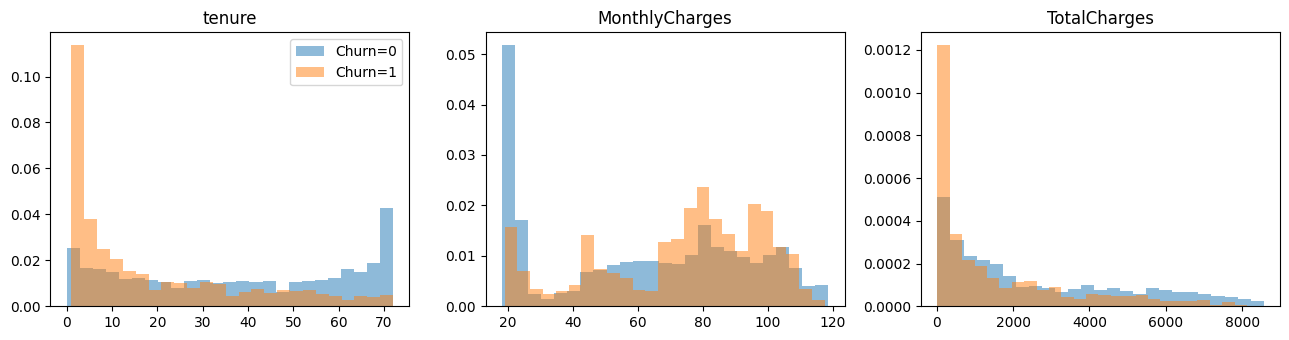

,count,churn_rate
Contract,,
Month-to-month,1932,0.435818
One year,787,0.109276
Two year,872,0.027523


,count,churn_rate
InternetService,,
DSL,1226,0.194943
Fiber optic,1585,0.407571
No,780,0.085897


,count,churn_rate
PaymentMethod,,
Bank transfer (automatic),788,0.168782
Credit card (automatic),777,0.144144
Electronic check,1185,0.451477
Mailed check,841,0.204518


In [4]:
display(X_train.isna().sum().sort_values(ascending=False).to_frame("missing_train"))
display(y_train.value_counts(normalize=True).rename(index={0:"No churn", 1:"Churn"}).to_frame("fraction"))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for label in [0, 1]:
        ax.hist(X_train.loc[y_train == label, c].dropna(), bins=25, alpha=0.5, density=True, label=f"Churn={label}")
    ax.set_title(c)
axes[0].legend()
plt.tight_layout(); plt.show()
train_eda = X_train.assign(Churn=y_train)
for c in ["Contract", "InternetService", "PaymentMethod"]:
    display(train_eda.groupby(c).Churn.agg(["count", "mean"]).rename(columns={"mean":"churn_rate"}))


## 4. Feature variants and preprocessing
Compare original features, original plus engineered features, and compact replacements. Six internet add-ons are collapsed only in the compact variant. Service counts do not necessarily carry the same information as individual services.

All imputers, encoders and scalers fit inside the pipeline, separately within each CV training fold. Unknown categories are supported. Dense encoding is practical for this small dataset.

In [5]:
ADDONS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
class TelcoFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, variant="original"):
        self.variant = variant
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        out = X.copy()
        if self.variant == "original":
            return out
        if self.variant not in ["augmented", "compact"]:
            raise ValueError("Unknown feature variant")
        # Pure row-wise transformations: no dataset statistics are learned here.
        out["AddonCount"] = out[ADDONS].eq("Yes").sum(axis=1).astype(float)
        out.loc[out[ADDONS].isna().any(axis=1), "AddonCount"] = np.nan
        support = ["OnlineSecurity", "OnlineBackup", "TechSupport"]
        out["SupportCount"] = out[support].eq("Yes").sum(axis=1).astype(float)
        out.loc[out[support].isna().any(axis=1), "SupportCount"] = np.nan
        out["AutoPayment"] = out.PaymentMethod.isin(["Bank transfer (automatic)", "Credit card (automatic)"]).astype(float)
        out.loc[out.PaymentMethod.isna(), "AutoPayment"] = np.nan
        out["TenureGroup"] = pd.cut(out.tenure, bins=[-np.inf, 6, 12, 24, 48, np.inf],
            labels=["0-6", "7-12", "13-24", "25-48", "49+"]).astype(object)
        out["TenureContract"] = out.TenureGroup.fillna("missing") + " | " + out.Contract.fillna("missing")
        out["ChargeFiberInteraction"] = out.MonthlyCharges * out.InternetService.eq("Fiber optic").astype(float)
        out.loc[out.InternetService.isna(), "ChargeFiberInteraction"] = np.nan
        if self.variant == "compact":
            out = out.drop(columns=ADDONS + ["PaymentMethod"])
        return out

def make_pipeline(model, variant="original"):
    numeric = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                            ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    prep = ColumnTransformer([("numeric", numeric, make_column_selector(dtype_include=np.number)),
                              ("categorical", categorical, make_column_selector(dtype_exclude=np.number))])
    return Pipeline([("features", TelcoFeatures(variant)), ("preprocess", prep), ("model", model)])
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=250, min_samples_leaf=3, random_state=SEED, n_jobs=1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED, early_stopping=False)
}
scoring = {"pr_auc":"average_precision", "roc_auc":"roc_auc", "precision":"precision", "recall":"recall", "f1":"f1"}


## 5. Compare models and feature variants
Primary ranking: average precision (a summary of the precision–recall curve). Precision, recall and F1 here use the default 0.5 cutoff. “Raw columns” differs from the number of encoded features. Repeated CV comparisons are exploratory; the selected CV score can be optimistic.

In [6]:
records = []
for variant in ["original", "augmented", "compact"]:
    for name, model in models.items():
        print("Evaluating:", variant, name)
        scores = cross_validate(make_pipeline(model, variant), X_train, y_train,
                                cv=cv, scoring=scoring, n_jobs=N_JOBS, error_score="raise")
        row = {"variant":variant, "model":name,
               "raw_columns":TelcoFeatures(variant).transform(X_train).shape[1]}
        for metric in scoring:
            row[metric] = scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = scores[f"test_{metric}"].std(ddof=1)
        records.append(row)
comparison = pd.DataFrame(records).sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / "cv_model_feature_comparison.csv", index=False)


Evaluating: original LogisticRegression
Evaluating: original RandomForest
Evaluating: original HistGradientBoosting
Evaluating: augmented LogisticRegression
Evaluating: augmented RandomForest
Evaluating: augmented HistGradientBoosting
Evaluating: compact LogisticRegression
Evaluating: compact RandomForest
Evaluating: compact HistGradientBoosting


,variant,model,raw_columns,pr_auc,pr_auc_std,roc_auc,roc_auc_std,precision,precision_std,recall,recall_std,f1,f1_std
0,augmented,LogisticRegression,26,0.6574,0.0266,0.8426,0.0090,0.6594,0.0134,0.5105,0.0250,0.5752,0.0191
1,compact,LogisticRegression,19,0.6573,0.0207,0.8430,0.0085,0.6615,0.0142,0.5042,0.0275,0.5718,0.0176
2,original,LogisticRegression,20,0.6437,0.0233,0.8382,0.0075,0.6321,0.0110,0.5221,0.0252,0.5717,0.0196
3,original,RandomForest,20,0.6414,0.0058,0.8348,0.0088,0.6586,0.0266,0.4842,0.0267,0.5579,0.0247
4,augmented,RandomForest,26,0.6376,0.0125,0.8356,0.0092,0.6577,0.0191,0.4842,0.0245,0.5575,0.0205
5,compact,RandomForest,19,0.6367,0.0046,0.8353,0.0100,0.6526,0.0206,0.4968,0.0165,0.5640,0.0160
6,original,HistGradientBoosting,20,0.6205,0.0118,0.8262,0.0108,0.6074,0.0419,0.5115,0.0425,0.5550,0.0399
7,compact,HistGradientBoosting,19,0.6190,0.0166,0.8247,0.0086,0.6071,0.0272,0.5136,0.0215,0.5563,0.0216
8,augmented,HistGradientBoosting,26,0.6169,0.0119,0.8239,0.0093,0.6055,0.0226,0.5210,0.0241,0.5600,0.0229


## 6. Tune the leading two model–feature combinations
Use the same training CV and average-precision objective. Class weights are candidates for logistic regression and Random Forest. No oversampling is performed before splitting or outside CV. This search is deliberately bounded so it can run on a laptop.

In [7]:
spaces = {
 "LogisticRegression": {"model__C":[0.01, 0.1, 1, 10, 100], "model__class_weight":[None, "balanced"]},
 "RandomForest": {"model__n_estimators":[250, 400], "model__max_depth":[None, 8, 16],
                  "model__min_samples_leaf":[1, 3, 6, 12], "model__max_features":["sqrt", 0.7],
                  "model__class_weight":[None, "balanced"]},
 "HistGradientBoosting": {"model__learning_rate":[0.03, 0.06, 0.1], "model__max_iter":[150, 250],
                          "model__max_leaf_nodes":[7, 15, 31], "model__l2_regularization":[0, 1, 10],
                          "model__min_samples_leaf":[20, 40]}
}
searches = []
for _, row in comparison.head(2).iterrows():
    name, variant = row["model"], row["variant"]
    space = spaces[name]
    count = int(np.prod([len(v) for v in space.values()]))
    search = RandomizedSearchCV(make_pipeline(models[name], variant), space,
        n_iter=min(SEARCH_ITERATIONS, count), scoring="average_precision", cv=cv,
        random_state=SEED, n_jobs=N_JOBS, refit=True, error_score="raise")
    search.fit(X_train, y_train)
    searches.append((name, variant, search))
    print(name, variant, "CV average precision:", round(search.best_score_, 4), search.best_params_)
    pd.DataFrame(search.cv_results_).to_csv(OUTPUT_DIR / f"tuning_{name}_{variant}.csv", index=False)
# A tuned candidate is not automatically better than the untuned baseline.
baseline_row = comparison.iloc[0]
best_tuned = max(searches, key=lambda item: item[2].best_score_)
if best_tuned[2].best_score_ >= baseline_row.pr_auc:
    selected_name, selected_variant, selected_search = best_tuned
    final_model = selected_search.best_estimator_
    selection_score = selected_search.best_score_
    selected_params = selected_search.best_params_
else:
    selected_name, selected_variant = baseline_row["model"], baseline_row["variant"]
    final_model = make_pipeline(models[selected_name], selected_variant).fit(X_train, y_train)
    selection_score = float(baseline_row.pr_auc)
    selected_params = {"selection":"untuned baseline retained"}
print("Frozen model:", selected_name, selected_variant)


LogisticRegression augmented CV average precision: 0.6574 {'model__class_weight': None, 'model__C': 1}
LogisticRegression compact CV average precision: 0.6573 {'model__class_weight': None, 'model__C': 1}
Frozen model: LogisticRegression augmented


## 7. Choose the threshold using validation only
F1 balances precision and recall. Recall-target mode maximizes precision among thresholds reaching the target. Cost mode minimizes illustrative FP/FN costs; it does not model whether an offer prevents churn. Validation results after choosing the best threshold are selection results, not an unbiased final score.

Keep the model trained on training data for final testing: refitting it on validation could change probability distributions and invalidate the selected threshold.

,threshold,precision,recall,f1,accuracy,alerts,tn,fp,fn,tp,cost
default,0.5000,0.6729,0.5710,0.6177,0.8129,269.0,792.0,88.0,136.0,181.0,768.0
selected,0.3666,0.6057,0.7413,0.6667,0.8037,388.0,727.0,153.0,82.0,235.0,563.0


Validation average precision: 0.6871


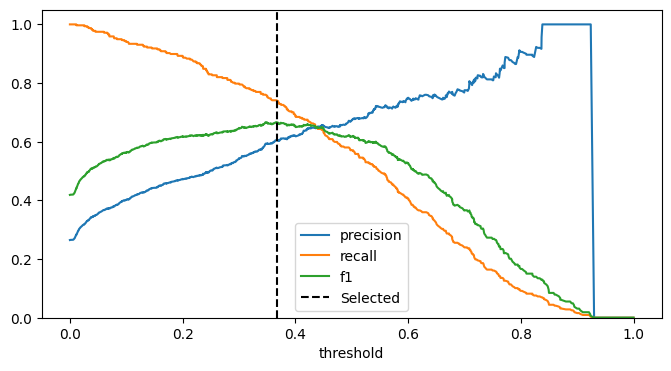

In [8]:
val_probability = final_model.predict_proba(X_val)[:, 1]
def metrics_at(y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"threshold":float(threshold), "precision":precision_score(y_true, prediction, zero_division=0),
            "recall":recall_score(y_true, prediction, zero_division=0),
            "f1":f1_score(y_true, prediction, zero_division=0),
            "accuracy":accuracy_score(y_true, prediction), "alerts":int(prediction.sum()),
            "tn":int(tn), "fp":int(fp), "fn":int(fn), "tp":int(tp),
            "cost":float(fn*FALSE_NEGATIVE_COST + fp*FALSE_POSITIVE_COST)}
thresholds = np.unique(np.r_[np.linspace(0, 1, 101), val_probability])
threshold_table = pd.DataFrame([metrics_at(y_val, val_probability, t) for t in thresholds])
if THRESHOLD_GOAL == "f1":
    chosen = threshold_table.sort_values(["f1", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
elif THRESHOLD_GOAL == "recall_target":
    feasible = threshold_table[threshold_table.recall >= RECALL_TARGET]
    if feasible.empty:
        raise ValueError("No threshold meets the recall target")
    chosen = feasible.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]
elif THRESHOLD_GOAL == "cost":
    chosen = threshold_table.sort_values(["cost", "threshold"], ascending=[True, False]).iloc[0]
else:
    raise ValueError("Unknown THRESHOLD_GOAL")
selected_threshold = float(chosen.threshold)
display(pd.DataFrame([metrics_at(y_val, val_probability, 0.5), chosen.to_dict()], index=["default", "selected"]).round(4))
print("Validation average precision:", round(average_precision_score(y_val, val_probability), 4))
threshold_table.to_csv(OUTPUT_DIR / "validation_thresholds.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 4))
threshold_table.plot(x="threshold", y=["precision", "recall", "f1"], ax=ax)
ax.axvline(selected_threshold, color="black", linestyle="--", label="Selected")
ax.set_ylim(0, 1.05); ax.legend(); plt.show()


## 8. Validation diagnostics
Permutation importance measures the decrease in validation average precision when an original input column is shuffled. Correlated predictors may share or hide importance. Do not use the test set to select features. Changing features after this section creates another experiment and requires renewed validation.

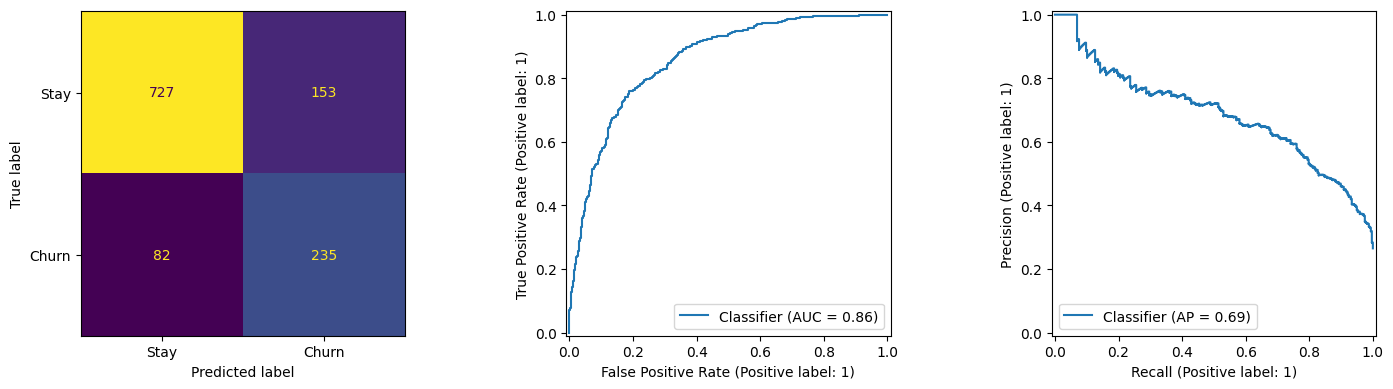

,feature,mean,std
5,tenure,0.1221,0.0217
15,Contract,0.0894,0.0185
8,InternetService,0.0766,0.0158
18,MonthlyCharges,0.0241,0.0068
19,TotalCharges,0.0166,0.0079
9,OnlineSecurity,0.0131,0.0031
14,StreamingMovies,0.0107,0.0029
16,PaperlessBilling,0.0081,0.0030
7,MultipleLines,0.0059,0.0029
12,TechSupport,0.0046,0.0016


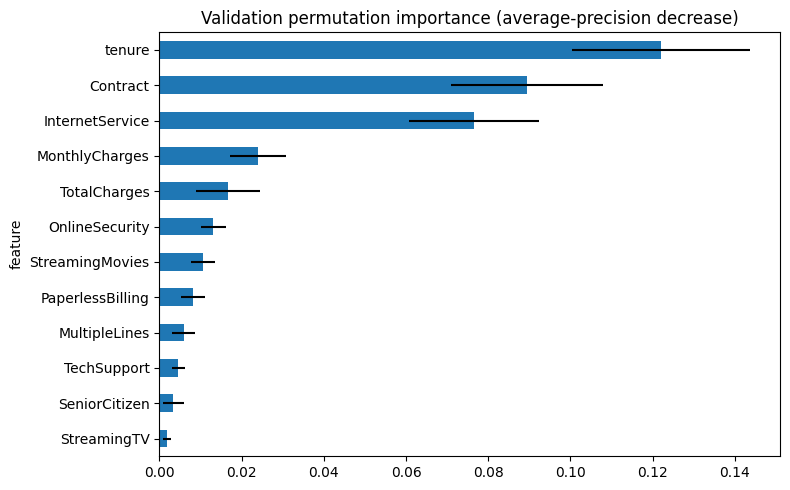

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(y_val, val_probability >= selected_threshold,
    labels=[0, 1], display_labels=["Stay", "Churn"], ax=axes[0], colorbar=False)
RocCurveDisplay.from_predictions(y_val, val_probability, ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_val, val_probability, ax=axes[2])
plt.tight_layout(); plt.show()
importance = permutation_importance(final_model, X_val, y_val, scoring="average_precision",
                                    n_repeats=5, random_state=SEED, n_jobs=N_JOBS)
importance_table = pd.DataFrame({"feature":X_val.columns, "mean":importance.importances_mean,
                                "std":importance.importances_std}).sort_values("mean", ascending=False)
display(importance_table.round(4))
importance_table.head(12).sort_values("mean").plot.barh(x="feature", y="mean", xerr="std", legend=False, figsize=(8, 5))
plt.title("Validation permutation importance (average-precision decrease)"); plt.tight_layout(); plt.show()
importance_table.to_csv(OUTPUT_DIR / "validation_permutation_importance.csv", index=False)


## 9. Optional final test — enable only when decisions are frozen
Set RUN_FINAL_TEST=True in the configuration, then run this cell after completing previous cells. Do not tune based on this result. A previously explored dataset warrants an exploratory label even with this split. No claim of improved performance can be made before execution.

,threshold,precision,recall,f1,accuracy,alerts,tn,fp,fn,tp,cost,roc_auc,average_precision
0,0.3666,0.5504,0.6352,0.5898,0.7654,367,715,165,116,202,745.0,0.8303,0.6247


              precision    recall  f1-score   support

        Stay       0.86      0.81      0.84       880
       Churn       0.55      0.64      0.59       318

    accuracy                           0.77      1198
   macro avg       0.71      0.72      0.71      1198
weighted avg       0.78      0.77      0.77      1198



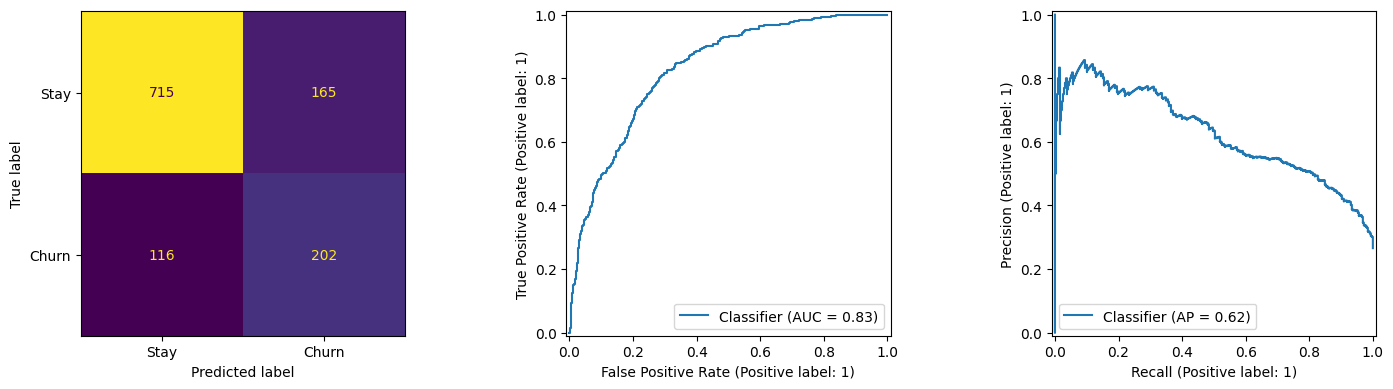

In [14]:
test_metrics = None
if RUN_FINAL_TEST:
    test_probability = final_model.predict_proba(X_test)[:, 1]
    test_metrics = metrics_at(y_test, test_probability, selected_threshold)
    test_metrics.update(roc_auc=roc_auc_score(y_test, test_probability),
                        average_precision=average_precision_score(y_test, test_probability))
    display(pd.DataFrame([test_metrics]).round(4))
    print(classification_report(y_test, test_probability >= selected_threshold,
                                target_names=["Stay", "Churn"], zero_division=0))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, test_probability >= selected_threshold,
        labels=[0, 1], display_labels=["Stay", "Churn"], ax=axes[0], colorbar=False)
    RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1])
    PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[2])
    plt.tight_layout(); plt.show()
    pd.DataFrame({"customerID":customer_ids.loc[X_test.index], "actual_churn":y_test,
                  "churn_probability":test_probability,
                  "predicted_churn":(test_probability >= selected_threshold).astype(int)}).to_csv(
                      OUTPUT_DIR / "test_predictions.csv", index=False)
    pd.DataFrame([test_metrics]).to_csv(OUTPUT_DIR / "final_test_metrics.csv", index=False)
else:
    print("Final test locked. Enable RUN_FINAL_TEST only after freezing decisions.")


## 10. Save and predict new customers
The bundle includes preprocessing, model, threshold and feature schema. Because TelcoFeatures is defined in this notebook, execute its definition before loading the bundle in a new notebook. For deployment move the class and ADDONS into an importable Python module and train/save again. Load only trusted joblib files. Raw model probabilities have not been calibrated; do not interpret them as proven individual churn likelihoods.

In [11]:
metadata = {
    "version":"v4", "seed":SEED, "model":selected_name, "feature_variant":selected_variant,
    "selected_parameters":selected_params, "cv_average_precision":float(selection_score),
    "threshold":selected_threshold, "threshold_goal":THRESHOLD_GOAL,
    "raw_feature_columns":list(X_train.columns), "sklearn_version":sklearn.__version__,
    "data_sha256":hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "training_rows":len(X_train), "validation_rows":len(X_val), "test_rows":len(X_test),
    "final_test_enabled":RUN_FINAL_TEST,
    "evaluation_note":"Exploratory if this dataset informed earlier decisions."
}
bundle = {"pipeline":final_model, "threshold":selected_threshold, "metadata":metadata}
joblib.dump(bundle, OUTPUT_DIR / "telco_churn_v4.joblib")
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2, default=str))

def predict_customers(raw_customers, bundle):
    data = raw_customers.copy()
    ids = data["customerID"].copy() if "customerID" in data else pd.Series(data.index, index=data.index)
    expected = bundle["metadata"]["raw_feature_columns"]
    missing = set(expected) - set(data.columns)
    if missing:
        raise ValueError(f"Missing predictor columns: {sorted(missing)}")
    data = data[expected].copy()
    for c in data.select_dtypes(include=["object", "string"]).columns:
        data[c] = data[c].str.strip().replace("", np.nan)
    for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
        data[c] = pd.to_numeric(data[c], errors="raise")
    probability = bundle["pipeline"].predict_proba(data)[:, 1]
    return pd.DataFrame({"customerID":ids.to_numpy(), "churn_score":probability,
                         "predicted_churn":(probability >= bundle["threshold"]).astype(int)}, index=data.index)
# Demonstrate with validation records, without accessing test records.
display(predict_customers(df.loc[X_val.index].head(5), bundle))
print("Saved outputs in", OUTPUT_DIR.resolve())


FileNotFoundError: [Errno 2] No such file or directory: 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

## 11. Write your conclusions after execution
- Which model and feature variant won on training CV? Was the difference larger than fold-to-fold variation?
- Did tuning beat the untuned model? Which features helped, and which lost information?
- What changed between threshold 0.5 and the selected cutoff: precision, recall, F1 and number of alerts?
- If enabled, how did final test performance compare with validation? Do not revise the model using that result.
- What is the business cost of missed churners versus unnecessary contacts? Retention effectiveness requires additional evidence.
- Limitations: static historical sample, previous dataset exposure, uncalibrated scores, no time-based external validation, and no causal inference.

V4 improves experimental discipline and makes model improvements testable. It does not guarantee a higher score.